In [11]:
import jax
import jax.numpy as jnp

def split_step_jax(A_0, t, Z, make_differential_operator: callable, make_nonlinear_operator: callable, n_integral_iterations = 10):
    '''
    So we find `N(z+h)` by running through the calculation assuming `N(z+h) = N(z)` to find `A(z+h)` to plug back in to find `N(z+h)`

    THIS CODE DOES NOT DO:
    $$e^{\frac{h}{2}D}[ e^{\frac{h}{2}N}e^{\frac{h}{2}D}A(z, T) e^{\frac{h}{2}N}e^{\frac{h}{2}D}A(z + h, T) ]$$

    It does
    $$e^{\frac{h}{2}D} e^{\frac{h}{2} ( N(A(z)) + N(A(z+h)) )} e^{\frac{h}{2}D} A(z)$$

    ```python
    N_start = N(A(z))
    N_end = N(A(z+h))
    DA_start = exp(D * h / 2) A(z, T)
    A_mid = exp(( N(A(z)) + N(A(z+h)) ) * h / 2) exp(D * h / 2) A(z, T)
    ```

    We have to fft n_integral_iterations times per step. You would think its 
    n_integral_iterations + 1, but you can save Af from the last iteration.
    '''
    dZ = Z[1] - Z[0]

    A = jnp.zeros((Z.size, A_0.size), dtype=complex)
    A = A.at[0].set(jnp.array(A_0))

    omega = 2 * jnp.pi * jnp.fft.fftfreq(A_0.size, d=t[1] - t[0])
    D = make_differential_operator(omega)
    differential_operator = jnp.exp( dZ / 2 * D )

    Af_start = jnp.fft.fft(A_0)
    for ind, A_start in enumerate(A[:-1]):
        A_end = jnp.copy(A_start)

        N_start = make_nonlinear_operator(A_start)
        DA_start = jnp.fft.ifft( differential_operator * Af_start )

        for refinement_ind in range(n_integral_iterations):
            if refinement_ind == 0:
                N_end = N_start
            else:
                N_end = make_nonlinear_operator(A_end)
            A_mid = jnp.exp( dZ / 2 * ( N_start + N_end ) ) * DA_start
            Af_end = differential_operator * jnp.fft.fft(A_mid)
            A_end = jnp.fft.ifft( Af_end )

        Af_start = Af_end
        A = A.at[ind + 1].set(A_end)
    return A

def split_step_single_jax(A_0, t, dZ, make_differential_operator: callable, make_nonlinear_operator: callable, n_integral_iterations = 10):
    '''
    So we find `N(z+h)` by running through the calculation assuming `N(z+h) = N(z)` to find `A(z+h)` to plug back in to find `N(z+h)`

    THIS CODE DOES NOT DO:
    $$e^{\frac{h}{2}D}[ e^{\frac{h}{2}N}e^{\frac{h}{2}D}A(z, T) e^{\frac{h}{2}N}e^{\frac{h}{2}D}A(z + h, T) ]$$

    It does
    $$e^{\frac{h}{2}D} e^{\frac{h}{2} ( N(A(z)) + N(A(z+h)) )} e^{\frac{h}{2}D} A(z)$$

    ```python
    N_start = N(A(z))
    N_end = N(A(z+h))
    DA_start = exp(D * h / 2) A(z, T)
    A_mid = exp(( N(A(z)) + N(A(z+h)) ) * h / 2) exp(D * h / 2) A(z, T)
    ```

    We have to fft n_integral_iterations times per step. You would think its 
    n_integral_iterations + 1, but you can save Af from the last iteration.
    '''

    omega = 2 * jnp.pi * jnp.fft.fftfreq(A_0.size, d=t[1] - t[0])
    D = make_differential_operator(omega)
    differential_operator = jnp.exp( dZ / 2 * D )
    
    A_start = jnp.array(A_0, dtype=jnp.complex64)
    Af_start = jnp.fft.fft(A_start)
    A_end = jnp.copy(A_start)

    N_start = make_nonlinear_operator(A_start)
    DA_start = jnp.fft.ifft( differential_operator * Af_start )

    def refinement(ind, N_end):
        A_mid = jnp.exp( dZ / 2 * ( N_start + N_end ) ) * DA_start
        Af_end = differential_operator * jnp.fft.fft(A_mid)
        A_end = jnp.fft.ifft( Af_end )
        return make_nonlinear_operator( A_end )

    N_end = jax.lax.fori_loop(0, n_integral_iterations - 1, refinement, N_start)
    A_mid = jnp.exp( dZ / 2 * ( N_start + N_end ) ) * DA_start
    Af_end = differential_operator * jnp.fft.fft(A_mid)
    A_end = jnp.fft.ifft( Af_end )
    return A_end

In [2]:
from NLSE import split_step_single_jax
import jax
import jax.numpy as jnp

alpha = 0.0018 # loss per rt
coupling_coeff = 0.0005 # Input coupling coeff (theta)
gamma = 0.9 # W^-1 m^-1
cavity_length = 0.63e-3 # m
alpha_int = 2 * alpha - coupling_coeff
alpha_int_per_m = alpha_int / cavity_length
t_rt = 5e-12 # s

beta_2 = -202 / ( 1e12 ** 2 ) / 1e3 # s^2 m^-1

intensity_in = 8.7 / ( gamma * cavity_length * coupling_coeff / alpha ** 3 )
# intensity_in = 0.18

ring_bus_bs = jnp.array([[jnp.sqrt(1 - coupling_coeff), 1j * jnp.sqrt(coupling_coeff)], 
                        [1j * jnp.sqrt(coupling_coeff), jnp.sqrt(1 - coupling_coeff)]])

In [5]:
tau = jnp.linspace(-t_rt / 2, t_rt / 2, 2048, endpoint=False)
tau_normalized = tau * jnp.sqrt( 2 * alpha / ( abs(beta_2) * cavity_length ) )

Ain = -1j * jnp.sqrt(intensity_in) * jnp.ones(tau.shape)
seed = jnp.sqrt(alpha / (gamma * cavity_length)) * jnp.sqrt(2 * 4.5) / jnp.cosh(jnp.sqrt(4.5) * tau_normalized)

detuning = 4.5 * alpha

ring_bus_detuning = jnp.array([[1, 0], [0, jnp.exp(-1j * detuning)]])
ring_bus = ring_bus_bs @ ring_bus_detuning

z = jnp.linspace(0, cavity_length, 2, endpoint=True)

n_rt = round( 10 / alpha )
# T = np.arange(0, n_rt)

In [ ]:
%%timeit
def nl_operator(A):
    return 1j * gamma * jnp.abs(A) ** 2

def diff_operator(omega):
    return 1j * beta_2 / 2 * omega ** 2

A_intra = [ seed ]
for ind in range(n_rt):
    A = split_step_single_jax(A_intra[ind], tau, cavity_length, diff_operator, nl_operator, n_integral_iterations=2)
    Anext = 1j * jnp.sqrt(coupling_coeff) * Ain + jnp.exp(-1j * detuning - alpha) * A
    A_intra.append(Anext)

In [3]:
def run_sim(A_init, Ain, time, cavity_length, nrt, detuning):
    _key_init = jax.random.key(0)
    _a_init = jnp.array(A_init, dtype=jnp.complex64)
    _a_in = jnp.array(Ain, dtype=jnp.complex64)
    
    def nl_operator(A):
        return 1j * gamma * jnp.abs(A) ** 2

    def diff_operator(omega):
        return 1j * beta_2 / 2 * omega ** 2

    def body_func(carry, ind):
        key, A = carry
        key, subkey = jax.random.split(key)
        
        A_stepped = split_step_single_jax(A, tau, cavity_length, diff_operator, nl_operator, n_integral_iterations=2)
        Anext = 1j * jnp.sqrt(coupling_coeff) * _a_in + jnp.exp(-1j * detuning - alpha) * A_stepped
        # return (key, Anext), None
        return (key, Anext), Anext
    
    carry, A_rest = jax.lax.scan(body_func, (_key_init, _a_init), jnp.arange(nrt))
    A = jnp.concat([_a_init[None,...], A_rest], axis=0)
    return A
    # carry, _ = jax.lax.scan(body_func, (_key_init, _a_init), xs=None, length=nrt)
    # return carry[1]

%timeit run_sim(seed, Ain, tau, cavity_length, n_rt, 4.5 * alpha)

run_sim_jit = jax.jit(run_sim, static_argnames=('nrt',))
%timeit run_sim_jit(seed, Ain, tau, cavity_length, n_rt, 4.5 * alpha).block_until_ready()
# a = run_sim(seed, Ain, tau, cavity_length, n_rt, detuning = 4.5 * alpha)
# print(n_rt)

In [8]:
def run_sim(A_init, Ain, time, cavity_length, nrt, detuning):
    _key_init = jax.random.key(0)
    _a_init = jnp.array(A_init, dtype=jnp.complex64)
    _af_init = jnp.fft.fft(_a_init)
    
    _a_in = jnp.array(Ain, dtype=jnp.complex64)
    _af_in = jnp.fft.fft(_a_in)
    
    def nl_operator(A):
        return 1j * gamma * jnp.abs(A) ** 2

    def diff_operator(omega):
        return 1j * beta_2 / 2 * omega ** 2

    def body_func(carry, ind):
        A, Af = carry
        
        A_prop, Af_prop = split_step_single_jax(A, Af, tau[1] - tau[0], cavity_length, diff_operator, nl_operator, n_integral_iterations=2)
        A_next = 1j * jnp.sqrt(coupling_coeff) * _a_in + jnp.exp(-1j * detuning - alpha) * A_prop
        Af_next = 1j * jnp.sqrt(coupling_coeff) * _af_in + jnp.exp(-1j * detuning - alpha) * Af_prop
        return (A_next, Af_next), A_next
    
    carry, A_rest = jax.lax.scan(body_func, (_a_init, _af_init), jnp.arange(nrt))
    A = jnp.concat([_a_init[None,...], A_rest], axis=0)
    return A
    # carry, _ = jax.lax.scan(body_func, (_key_init, _a_init), xs=None, length=nrt)
    # return carry[1]

%timeit run_sim(seed, Ain, tau, cavity_length, n_rt, 4.5 * alpha)

run_sim_jit = jax.jit(run_sim, static_argnames=('nrt',))
%timeit run_sim_jit(seed, Ain, tau, cavity_length, n_rt, 4.5 * alpha).block_until_ready()
# a = run_sim(seed, Ain, tau, cavity_length, n_rt, detuning = 4.5 * alpha)
# print(n_rt)

445 ms ± 1.02 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
433 ms ± 3.52 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


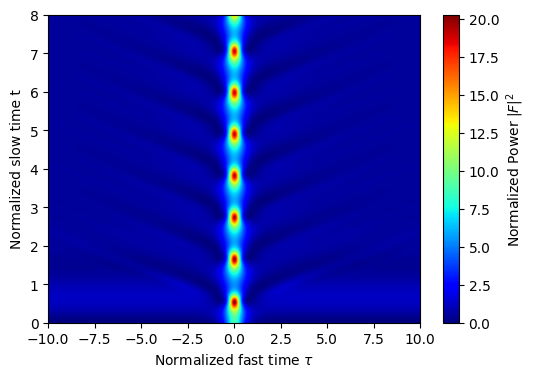

In [6]:
import matplotlib.pyplot as plt

a = run_sim_jit(seed, Ain, tau, cavity_length, n_rt, detuning = 4.5 * alpha)
F_intra = jnp.array(a) * jnp.sqrt(gamma * cavity_length / alpha)

plt.figure(figsize=(6,4))
plt.imshow(jnp.abs(F_intra[::-1])**2, extent=[jnp.min(tau_normalized), jnp.max(tau_normalized), 0, 8], aspect='auto', cmap='jet')
plt.xlim(-10, 10)
plt.xlabel('Normalized fast time $\\tau$')
plt.ylabel('Normalized slow time t')
plt.colorbar(label='Normalized Power $|F|^2$')
plt.show()

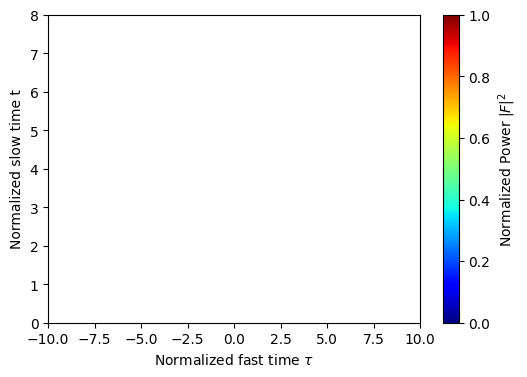

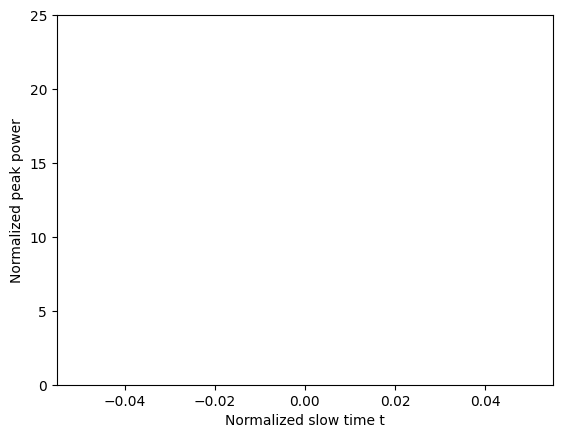

In [131]:
import matplotlib.pyplot as plt

start = round( 1.34 / alpha )
end = round(9.34 / alpha)
F_intra = jnp.array(a[start:end]) * jnp.sqrt(gamma * cavity_length / alpha)

plt.figure(figsize=(6,4))
plt.imshow(jnp.abs(F_intra[::-1])**2, extent=[jnp.min(tau_normalized), jnp.max(tau_normalized), 0, 8], aspect='auto', cmap='jet')
plt.xlim(-10, 10)
plt.xlabel('Normalized fast time $\\tau$')
plt.ylabel('Normalized slow time t')
plt.colorbar(label='Normalized Power $|F|^2$')
plt.show()

F_max = jnp.amax(jnp.abs(F_intra) ** 2, axis=1)
slow_time = 8 * jnp.arange(len(F_max)) / len(F_max)
plt.plot(slow_time, F_max)
plt.ylim(0, 25)
plt.xlabel('Normalized slow time t')
plt.ylabel('Normalized peak power')
plt.show()

In [87]:
c = 299792458
hbar = 1.054571817e-34 # J s
omega_0 = 2 * jnp.pi * c / 1550e-9

# vacuum_noise = np.sqrt(hbar * omega_0 * alpha / 2 * 1 / t_rt)
vacuum_noise = jnp.sqrt(hbar * omega_0 / t_rt)

In [98]:
key = jax.random.key(0)

jax.random.uniform(key, (100))
key, subkey = jax.random.split(key)
jax.random.uniform(key, (100))

Array([0.8423141 , 0.18237865, 0.2271781 , 0.12072563, 0.19181347,
       0.722015  , 0.7654456 , 0.15254045, 0.9517063 , 0.02931046,
       0.09871054, 0.55314326, 0.12444711, 0.59456205, 0.9594908 ,
       0.6932272 , 0.72409594, 0.31816435, 0.82007146, 0.64102626,
       0.26298678, 0.192016  , 0.7758906 , 0.85607576, 0.81815505,
       0.3112465 , 0.8128619 , 0.95005536, 0.00593698, 0.670676  ,
       0.96541536, 0.12037003, 0.27802575, 0.9841027 , 0.7886889 ,
       0.421736  , 0.0409466 , 0.20570374, 0.00907171, 0.9397465 ,
       0.92005277, 0.6369729 , 0.52490294, 0.87431717, 0.4158759 ,
       0.36705065, 0.75454223, 0.36721492, 0.68864214, 0.5837884 ,
       0.0349462 , 0.970229  , 0.80099404, 0.95427346, 0.9501376 ,
       0.22017467, 0.8866005 , 0.16572583, 0.8579055 , 0.42967844,
       0.80613124, 0.6573353 , 0.26733792, 0.59110713, 0.00650835,
       0.23731565, 0.42566156, 0.99145687, 0.03624403, 0.15002811,
       0.10239637, 0.06670845, 0.53395545, 0.96418786, 0.89932

In [95]:
normalized_detuning = jnp.arange(-2.9, 12, 0.01)
detuning = alpha * normalized_detuning

n_rt = round( 1 / alpha )
# n_rt = 5

A_intra = [ jnp.zeros(tau.shape) ]
for det in detuning:
    _intra = A_intra[-1]
    for _ in range(n_rt):
        noise = vacuum_noise * jnp.exp(2j * jnp.pi * jnp.random.rand(*seed.shape))
        A = split_step(_intra, tau, z, diff_operator, nl_operator, n_integral_iterations=10)
        _intra = 1j * np.sqrt(coupling_coeff) * Ain + noise + np.exp(-1j * det - alpha) * A[-1]
        # Aout, Anext = ring_bus @ [Ain, A[-1]]
        # _intra.append(Anext)
    A_intra.append(_intra)

AttributeError: module 'jax.numpy' has no attribute 'random'